# Budgeted MLMC vs MLQMC for the Analytic Function 

## Imports

In [1]:
import mlqmcpy as mp
from mlqmcpy.problems import analytic, elliptic, asian_option

In [2]:
import numpy as np
import scipy.stats
import qmcpy as qp
import os

In [3]:
import torch 
torch.set_default_dtype(torch.float64)

In [4]:
import matplotlib 
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
COLORS = ['xkcd:purple', 'xkcd:green', 'xkcd:blue', 'xkcd:red', 'xkcd:turquoise', 'xkcd:pink', 'xkcd:brown', 'xkcd:light blue', 'xkcd:teal', 'xkcd:orange']
pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
WIDTH = 2*(500/72)
LW = 3
alpha = .2

## Experiment

In [5]:
force_experiment = True
problem_dim_levels = (analytic,2,3)
#problem_dim_levels = (elliptic,8,3)
#problem_dim_levels = (asian_option,12,5)
problem,dimension,num_levels = problem_dim_levels
datafile = "budgeted_comparison_data/comp.%s.d%d.levels%d.tmp"%(problem.__name__,dimension,num_levels)
if not os.path.isfile(datafile+".npy") or force_experiment:
    # parameters 
    initial_sample_size = 2**(num_levels-np.arange(num_levels)+3)
    max_budgets = 2**np.arange(6,11)
    trials = 100
    n_ref = 2**19
    zip_IteratorClass_DiscreteDistribClass = [
        (mp.GreedyMLMCIterator,qp.IIDStdUniform,"MLMC IID"),
        #(mp.GreedyMLQMCIterator,qp.Lattice,"R-MLQMC Lattice"),
        (mp.GreedyMLQMCIterator,qp.DigitalNetB2,"R-MLQMC DNet"),
        #(mp.GreedyFastGaussianProcessMLQMCIterator,qp.Lattice,"IGP-MLQMC Lattice"),
        (mp.GreedyGaussianProcessMLQMCIterator,qp.DigitalNetB2,"Standard IGP-MLQMC DNet"),
        (mp.GreedyFastGaussianProcessMLQMCIterator,qp.DigitalNetB2,"Fast IGP-MLQMC DNet"),
        #(mp.FastMultiTaskGaussianProcessMLQMCIterator,qp.Lattice,"MTGP-MLQMC Lattice"),
        #(mp.FastMultiTaskGaussianProcessMLQMCIterator,qp.DigitalNetB2,"MTGP-MLQMC DNet"),
    ]
    # experiment
    names = [name for (IteratorClass,DiscreteDistribClass,name) in zip_IteratorClass_DiscreteDistribClass]
    if hasattr(problem,"exact") and hasattr(problem.exact,"Q") and hasattr(problem.exact.Q,"mean"):
        true_solution = problem.exact.Q.mean(level=num_levels-1)
    else:
        x = qp.DigitalNetB2(dimension)(n_ref)
        y = problem(num_levels-1,x)
        true_solution = y.mean()
    cost_per_level = 2.**(np.arange(num_levels)-num_levels+1) # Rescale so that finest level has unit cost
    print("max_budgets: %s"%max_budgets)
    print("cost_per_level: %s"%str(cost_per_level))
    print("initial_sample_size: %s"%str(initial_sample_size))
    print("initial cost: %.1f"%(cost_per_level*initial_sample_size).sum())
    print("true_solution = %.5e"%true_solution)
    print()
    costs = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    means = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    std_errors = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    true_errors = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    for i,(IteratorClass,DiscreteDistribClass,name) in enumerate(zip_IteratorClass_DiscreteDistribClass):
        print("%s"%name)
        for j in range(len(max_budgets)):
            max_budget = max_budgets[j]
            print("\tbudget = %d"%max_budget)
            for t in range(trials):
                kwargs = {} if IteratorClass==mp.GreedyMLMCIterator else {"discrete_distribution_type": DiscreteDistribClass}
                iterator = IteratorClass(
                    dimension,
                    initial_sample_size=initial_sample_size,
                    cost_per_level=cost_per_level,
                    max_budget = max_budget,
                    **kwargs)
                problem_l_or_ml = problem if isinstance(iterator,mp.FastMultiTaskGaussianProcessMLQMCIterator) else problem.ml
                problem_tf = (lambda level,x: problem_l_or_ml(level,1-2*np.abs(x-1/2))) if DiscreteDistribClass==qp.Lattice else problem_l_or_ml
                for iter, new_samples in enumerate(iterator):
                    new_results = {level: problem_tf(level,samples) for level,samples in new_samples.items()}
                    iterator.update(new_results)
                costs[i,j,t] = iterator.cost
                means[i,j,t] = iterator.mean
                std_errors[i,j,t] = iterator.standard_error
                true_errors[i,j,t] = np.abs(true_solution-means[i,j,t])
                if t%20==0:
                    print("\t\ttrial: %-6d iteration: %-6d cost: %-10d mean: %-15.3e std error: %-15.3e true error: %-15.3e"%\
                    (t,iter,costs[i,j,t],means[i,j,t],std_errors[i,j,t],true_errors[i,j,t]))
        print()
    data = {
        "dimension": dimension,
        "num_levels": num_levels,
        "initial_sample_size": initial_sample_size,
        "max_budgets": max_budgets,
        "names": names,
        "costs": costs,
        "means": means,
        "std_errors": std_errors,
        "true_errors": true_errors,
    }
    np.save(datafile+".npy",data)
else:
    data = np.load(datafile+".npy",allow_pickle=True)[()]
    dimension = data["dimension"]
    num_levels = data["num_levels"]
    initial_sample_size = data["initial_sample_size"]
    max_budgets = data["max_budgets"]
    names = data["names"]
    costs = data["costs"]
    means = data["means"]
    std_errors = data["std_errors"]
    true_errors = data["true_errors"]
    trials = costs.shape[-1]

max_budgets: [  64  128  256  512 1024]
cost_per_level: [0.25 0.5  1.  ]
initial_sample_size: [64 32 16]
initial cost: 48.0
true_solution = 5.74622e-01

MLMC IID
	budget = 64
		trial: 0      iteration: 1      cost: 64         mean: 5.411e-01       std error: 4.219e-02       true error: 3.350e-02      
		trial: 20     iteration: 1      cost: 64         mean: 5.464e-01       std error: 3.971e-02       true error: 2.821e-02      
		trial: 40     iteration: 1      cost: 64         mean: 5.677e-01       std error: 3.998e-02       true error: 6.908e-03      
		trial: 60     iteration: 1      cost: 64         mean: 5.242e-01       std error: 3.800e-02       true error: 5.044e-02      
		trial: 80     iteration: 1      cost: 64         mean: 5.911e-01       std error: 3.873e-02       true error: 1.648e-02      
	budget = 128
		trial: 0      iteration: 3      cost: 160        mean: 6.108e-01       std error: 2.921e-02       true error: 3.615e-02      
		trial: 20     iteration: 3      cost: 160

## Analysis

above 0 means it is over budget, below 0 means it is within the budget
as only the FastMultiTaskGaussianProcessMLQMCIterator stays within budget, the rest of the notebook should be taken with a grain of salt


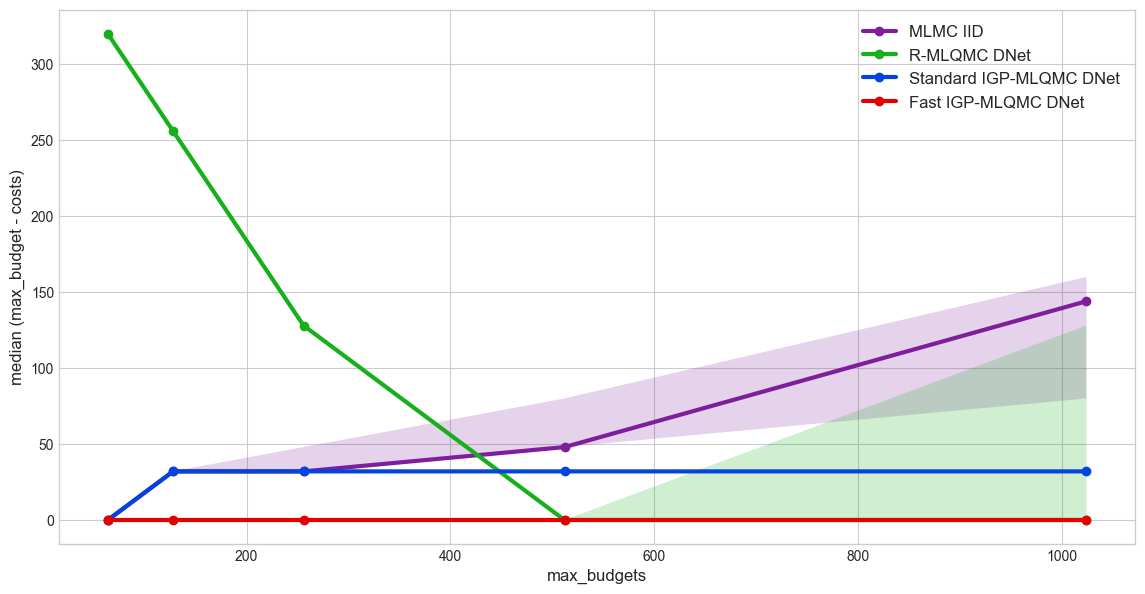

In [6]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH,WIDTH/2))
for i,name in enumerate(names):
    vals = costs[i]-max_budgets[:,None]
    q_low = np.nanquantile(vals,.25,axis=1)
    q_med = np.nanquantile(vals,.5,axis=1)
    q_high = np.nanquantile(vals,.75,axis=1)
    ax.plot(max_budgets,q_med,'-o',label=name,linewidth=LW)
    ax.fill_between(max_budgets,q_low,q_high,alpha=alpha)
ax.legend(frameon=False,fontsize="large")
ax.set_xlabel("max_budgets",fontsize="large")
ax.set_ylabel("median (max_budget - costs)",fontsize="large");
print("above 0 means it is over budget, below 0 means it is within the budget")
print("as only the FastMultiTaskGaussianProcessMLQMCIterator stays within budget, the rest of the notebook should be taken with a grain of salt")

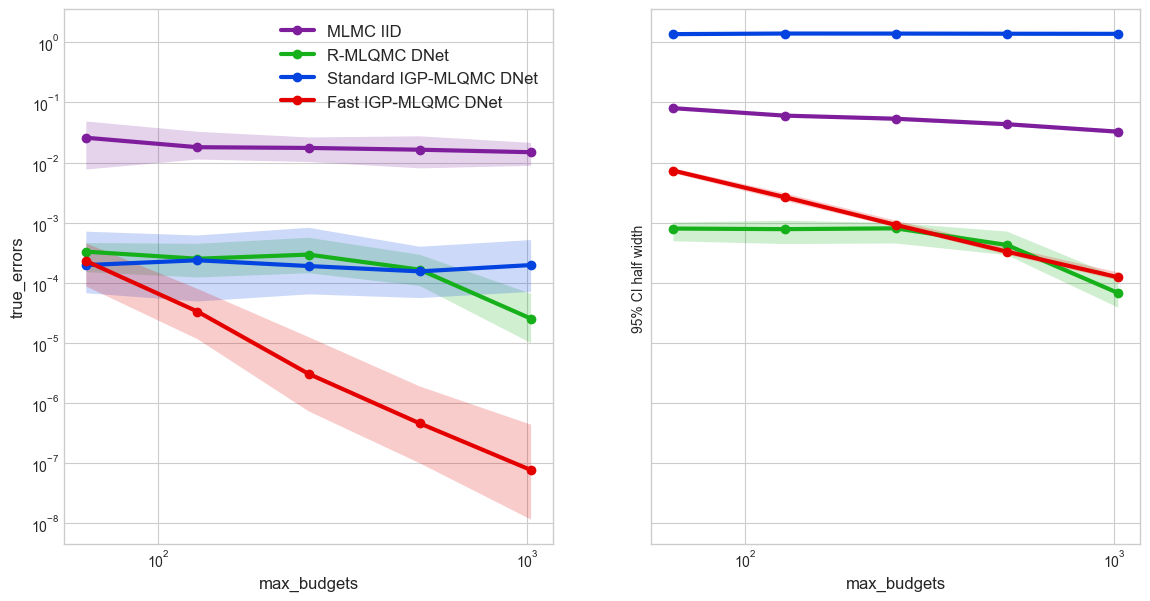

In [7]:
confidence = .95
beta = scipy.stats.norm.ppf(1-(1-confidence)/2)
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(WIDTH,WIDTH/2),sharey=True,sharex=True)
for i,name in enumerate(names):
    for j,vals in enumerate([true_errors[i],beta*std_errors[i]]):
        q_low = np.nanquantile(vals,.25,axis=1)
        q_med = np.nanquantile(vals,.5,axis=1)
        q_high = np.nanquantile(vals,.75,axis=1)
        ax[j].plot(max_budgets,q_med,'-o',label=name,linewidth=LW)
        #ax[j].scatter(costs[i],vals,color=COLORS[i])
        ax[j].fill_between(max_budgets,q_low,q_high,alpha=alpha)
ax[0].legend(frameon=False,fontsize="large")
ax[0].set_yscale("log",base=10)
ax[0].set_xscale("log",base=10)
ax[0].set_ylabel("true_errors",fontsize="large")
ax[1].set_ylabel("%d%% CI half width "%int(100*confidence))
for j in range(2):
    ax[j].set_xlabel("max_budgets",fontsize="large")

/var/folders/xk/w1s5c54x0zv90dgqk3vpmbsw004hmz/T/ipykernel_73832/304726523.py:10


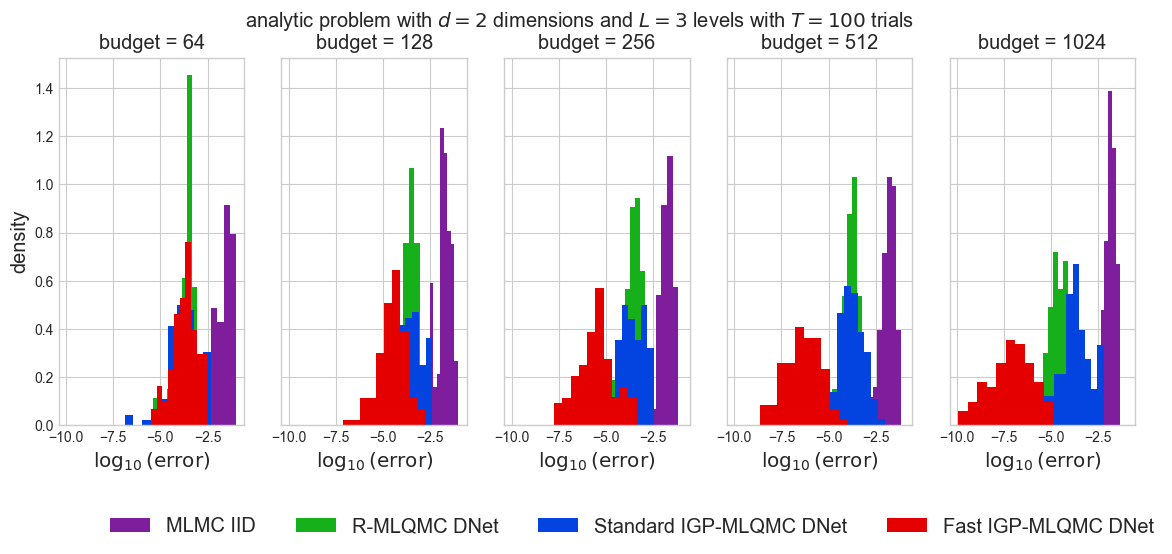

In [8]:
fig,ax = pyplot.subplots(nrows=1,ncols=len(max_budgets),figsize=(WIDTH,WIDTH/len(max_budgets)+2),sharex=True,sharey=True)
for j in range(len(max_budgets)):
    for i,name in enumerate(names):
        ax[j].hist(np.log10(true_errors[i,j]),label=name,density=True,bins=10) 
    ax[j].set_xlabel(r"$\log_{10}(\mathrm{error})$",fontsize="x-large")
    ax[j].set_title("budget = %d"%max_budgets[j],fontsize="x-large")
ax[0].legend(frameon=False,fontsize="x-large",ncol=len(names),bbox_to_anchor=(6,-.2))
ax[0].set_ylabel("density",fontsize="x-large")
fig.suptitle(r"%s problem with $d = %d$ dimensions and $L = %d$ levels with $T=%d$ trials"%(problem.__name__,dimension,num_levels,trials),fontsize="x-large")
fig.tight_layout()
#ax[0].set_xscale("log",base=10)
fig.savefig(datafile+".densities.pdf",transparent=True,bbox_inches="tight")

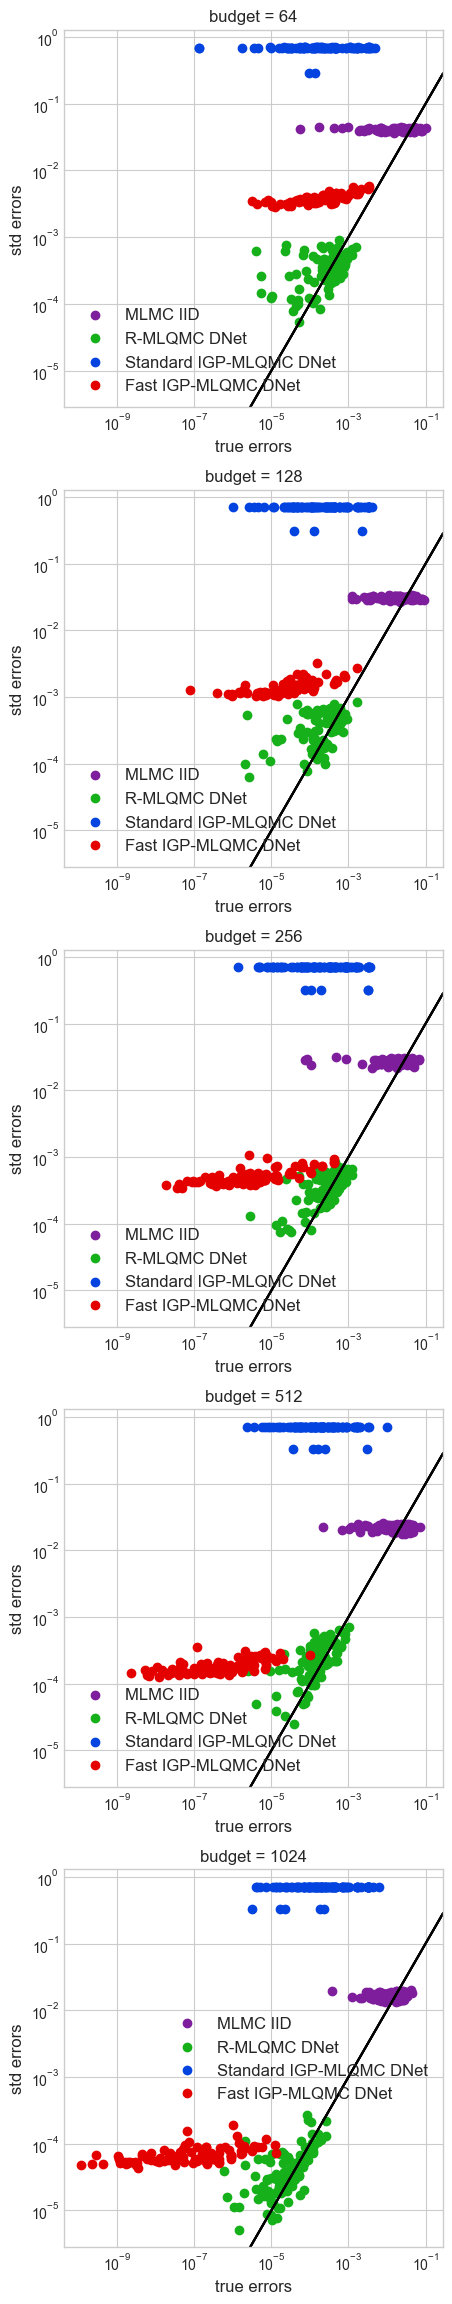

In [9]:
fig,ax = pyplot.subplots(nrows=len(max_budgets),ncols=1,figsize=(WIDTH/3,WIDTH*len(max_budgets)/3),sharex=True,sharey=True)
for i,name in enumerate(names):
    for j in range(len(max_budgets)):
        ax[j].scatter(true_errors[i,j],std_errors[i,j],label=name)
        ax[j].axline(xy1=(0,0),slope=1,color="k")
ax[0].set_xscale("log",base=10)
ax[0].set_yscale("log",base=10)
for j in range(len(max_budgets)):
    ax[j].legend(frameon=False,fontsize="large")#,ncols=len(max_budgets),bbox_to_anchor=(10,-.25))
    ax[j].set_xlabel("true errors",fontsize="large")
    ax[j].set_title("budget = %d"%max_budgets[j])
    ax[j].xaxis.set_tick_params(labelbottom=True)
    ax[j].set_ylabel("std errors",fontsize="large")
fig.tight_layout()